In [1]:
import numpy as np
import pandas as pd
from astroquery.gaia import Gaia
from astroquery.simbad import Simbad
import matplotlib.pyplot as plt
from astropy.table import Column, join, Table, vstack, hstack
from astropy.io import ascii
from HMXB_pipeline_class import pipeline
import astropy.coordinates as coords
import astropy.units as u
import os
from Galactic_traceback import GalacticTraceback

# Hugo, Simo and Jorge star

Gaia DR3 413455718252376448


In [2]:
cwd = os.getcwd()
cwd
home_files = os.path.dirname(cwd)
home_files = home_files + '/'
csv_files  = home_files + 'DATA/'
csv_files

'/home/karan/Documents/UvA/Thesis/DATA/'

In [3]:
hd7636 = ascii.read(csv_files+'HD 7636-result.ecsv',format='ecsv')

In [4]:
hd7636

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
413455718252376448,19.359576400806894,0.016940562,57.63207684364546,0.023316417,2.145612584825727,0.023034366,1.3529903627226807,0.031231841,126.42007126605573,-5.063473778063936,1.1324055995057507,0.036523424,--,--,-0.60169554,0.08620364,0.054607358,-0.081112534,-0.12539975,-0.07907663,0.01265649,0.056228034,-0.11142682,-0.61402726


Add RV

In [5]:
hd7636['RV'] = -18.0*u.km/u.s
hd7636['RV_err'] = 1.0 *u.km/u.s 

hd7636['Name'] = 'HD 7636'
hd7636['Mod_SpType'] = 'xkcd:blue'

In [6]:
hd7636

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,RV,RV_err,Name,Mod_SpType
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,,km / s,km / s,,
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,str7,str9
413455718252376448,19.359576400806894,0.016940562,57.63207684364546,0.023316417,2.145612584825727,0.023034366,1.3529903627226807,0.031231841,126.42007126605573,-5.063473778063936,1.1324055995057507,0.036523424,--,--,-0.60169554,0.08620364,0.054607358,-0.081112534,-0.12539975,-0.07907663,0.01265649,0.056228034,-0.11142682,-0.61402726,-18.0,1.0,HD 7636,xkcd:blue


In [7]:
bailer_jones = ascii.read(csv_files+'HD_7636_bailer_jones.csv',format='csv')

bailer_jones['r_med_photogeo'] = bailer_jones['r_med_photogeo']/1000
bailer_jones['r_med_photogeo'].unit = u.kpc

bailer_jones['r_hi_photogeo'] = bailer_jones['r_hi_photogeo']/1000
bailer_jones['r_hi_photogeo'].unit = u.kpc

bailer_jones['r_lo_photogeo'] = bailer_jones['r_lo_photogeo']/1000
bailer_jones['r_lo_photogeo'].unit = u.kpc
bailer_jones.rename_columns(['r_med_photogeo', 'r_lo_photogeo', 'r_hi_photogeo'], ['distance_bj','distance_bj_low','distance_bj_high'])

In [8]:
bailer_jones

source_id,distance_bj,distance_bj_low,distance_bj_high
,kpc,kpc,kpc
int64,float64,float64,float64
413455718252376448,0.85364417,0.8288055000000001,0.8850141


In [9]:
hd7636 = join(hd7636,bailer_jones, keys='source_id',join_type='left')
hd7636.write(csv_files+'hd7636_for_analysis.ecsv',format='ascii.ecsv',overwrite=True)

In [10]:
hd7636_pipeline = pipeline(csv_files+'hd7636_for_analysis.ecsv',fmt='ecsv')

In [11]:
hd7636_table= hd7636_pipeline.lay_pipe(filename=csv_files+f'hd7636_complete_analysis.ecsv',filetype='ascii.ecsv')

In [12]:
hd7636_table

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,RV,RV_err,Name,Mod_SpType,distance_bj,distance_bj_low,distance_bj_high,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,,km / s,km / s,,,kpc,kpc,kpc,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,str7,str9,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
413455718252376448,19.359576400806894,0.016940562,57.63207684364546,0.023316417,2.145612584825727,0.023034366,1.3529903627226807,0.031231841,126.42007126605573,-5.063473778063936,1.1324055995057507,0.036523424,--,--,-0.60169554,0.08620364,0.054607358,-0.081112534,-0.12539975,-0.07907663,0.01265649,0.056228034,-0.11142682,-0.61402726,-18.0,1.0,HD 7636,xkcd:blue,0.85364417,0.8288055000000001,0.8850141,0.8830758170362807,1.9828481774198954,1.5819448129077032,8.68183645731505,240.08348643491982,178.92868318709378,4.143303455134109,-1.9697905731605945,-3.8433033095679927,-4.26918440991124,-0.18646886025612486,-9.071036517549848,17.36643820212622,-5.085660172882159,2.108729132197027,3.7382042463244227,18.09577617076175,0.02848180244109845


# erors


In [13]:
hd7636_jacobian =ascii.read(csv_files+"hd7636_jacobian.ecsv",format='ecsv')
hd7636_vpec_err = ascii.read(csv_files+'hd7636_vpec_errs.ecsv',format='ecsv')

In [14]:
hd7636_jacobian

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,RV,RV_err,Name,Mod_SpType,distance_bj,distance_bj_low,distance_bj_high,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,l_err,b_err,pm_l_err,pm_b_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,,km / s,km / s,,,kpc,kpc,kpc,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,str7,str9,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
413455718252376448,19.359576400806894,0.016940562,57.63207684364546,0.023316417,2.145612584825727,0.023034366,1.3529903627226807,0.031231841,126.42007126605573,-5.063473778063936,1.1324055995057507,0.036523424,--,--,-0.60169554,0.08620364,0.054607358,-0.081112534,-0.12539975,-0.07907663,0.01265649,0.056228034,-0.11142682,-0.61402726,-18.0,1.0,HD 7636,xkcd:blue,0.85364417,0.8288055000000001,0.8850141,0.8830758170362807,1.9828481774198954,1.5819448129077032,8.68183645731505,240.08348643491982,178.92868318709378,4.143303455134109,-1.9697905731605945,-3.8433033095679927,-4.26918440991124,-0.18646886025612486,-9.071036517549848,17.36643820212622,-5.085660172882159,2.108729132197027,3.7382042463244227,18.09577617076175,0.02848180244109845,0.017169791992193706,0.014498460971119658,0.023349417157618745,0.01951061742055033


In [15]:
hd7636_table = join(hd7636, hd7636_vpec_err,keys='source_id',join_type='left')

In [16]:
hd7636_table = join(hd7636_jacobian, hd7636_vpec_err,keys='source_id',join_type='left')

In [17]:
hd7636_table

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,RV,RV_err,Name,Mod_SpType,distance_bj,distance_bj_low,distance_bj_high,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,l_err,b_err,pm_l_err,pm_b_err,V_pec_tan_err,V_pec_3d_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,,km / s,km / s,,,kpc,kpc,kpc,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,,km / s,km / s
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,str7,str9,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
413455718252376448,19.359576400806894,0.016940562,57.63207684364546,0.023316417,2.145612584825727,0.023034366,1.3529903627226807,0.031231841,126.42007126605573,-5.063473778063936,1.1324055995057507,0.036523424,--,--,-0.60169554,0.08620364,0.054607358,-0.081112534,-0.12539975,-0.07907663,0.01265649,0.056228034,-0.11142682,-0.61402726,-18.0,1.0,HD 7636,xkcd:blue,0.85364417,0.8288055000000001,0.8850141,0.8830758170362807,1.9828481774198954,1.5819448129077032,8.68183645731505,240.08348643491982,178.92868318709378,4.143303455134109,-1.9697905731605945,-3.8433033095679927,-4.26918440991124,-0.18646886025612486,-9.071036517549848,17.36643820212622,-5.085660172882159,2.108729132197027,3.7382042463244227,18.09577617076175,0.02848180244109845,0.017169791992193706,0.014498460971119658,0.023349417157618745,0.01951061742055033,1.9257400171188679,4.341240105053554


In [18]:
hd7636_table2 = Table(hd7636_table)
hd7636_table2.rename_columns(['pm_l_poleski', 'pm_b_poleski', 'Peculiar Velocity'], ['pm_l','pm_b','Tangential Peculiar Velocity'])

In [19]:
hd7636_table2.remove_columns(['radial_velocity','radial_velocity_error','Mod_SpType'])

In [20]:
hd7636_table2.write(csv_files+'hd7636_with_vpec.ecsv',format='ascii.ecsv',overwrite=True)
hd7636_table2.write(csv_files+'hd7636_with_vpec.csv',format='ascii.csv',overwrite=True)

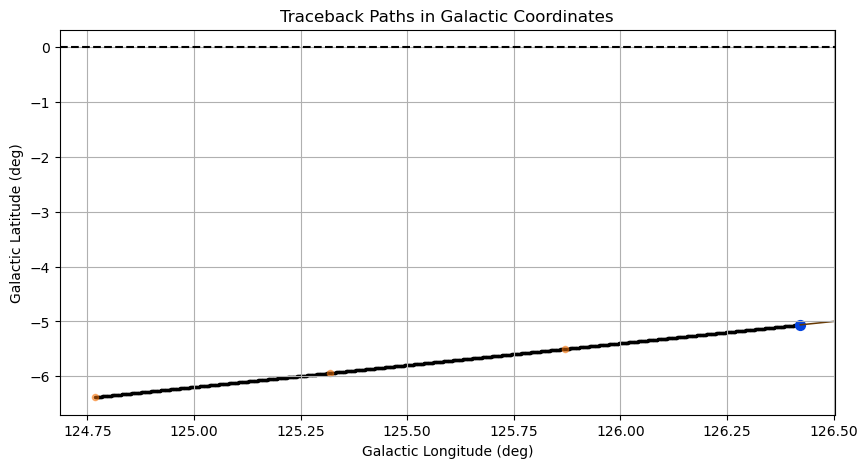

In [21]:
linear_path_hd7636 = GalacticTraceback(hd7636_table,int_time=-3.0).plot_trace(savefig=True)

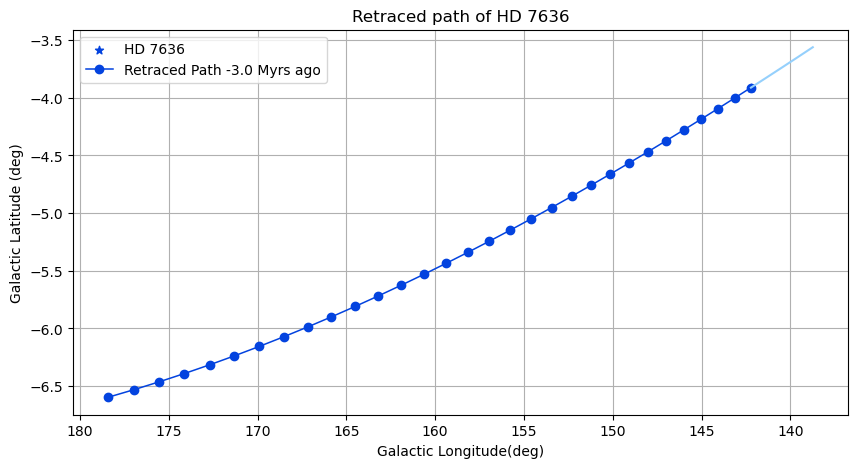

In [22]:
orbit_hd7636  = GalacticTraceback(hd7636_table,int_time=-3.0).plot_with_cluster(clustername=None,savefig=True)

In [23]:
hd7636_table

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,RV,RV_err,Name,Mod_SpType,distance_bj,distance_bj_low,distance_bj_high,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,l_err,b_err,pm_l_err,pm_b_err,V_pec_tan_err,V_pec_3d_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,,km / s,km / s,,,kpc,kpc,kpc,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,,km / s,km / s
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,str7,str9,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
413455718252376448,19.359576400806894,0.016940562,57.63207684364546,0.023316417,2.145612584825727,0.023034366,1.3529903627226807,0.031231841,126.42007126605573,-5.063473778063936,1.1324055995057507,0.036523424,--,--,-0.60169554,0.08620364,0.054607358,-0.081112534,-0.12539975,-0.07907663,0.01265649,0.056228034,-0.11142682,-0.61402726,-18.0,1.0,HD 7636,xkcd:blue,0.85364417,0.8288055000000001,0.8850141,0.8830758170362807,1.9828481774198954,1.5819448129077032,8.68183645731505,240.08348643491982,178.92868318709378,4.143303455134109,-1.9697905731605945,-3.8433033095679927,-4.26918440991124,-0.18646886025612486,-9.071036517549848,17.36643820212622,-5.085660172882159,2.108729132197027,3.7382042463244227,18.09577617076175,0.02848180244109845,0.017169791992193706,0.014498460971119658,0.023349417157618745,0.01951061742055033,1.9257400171188679,4.341240105053554


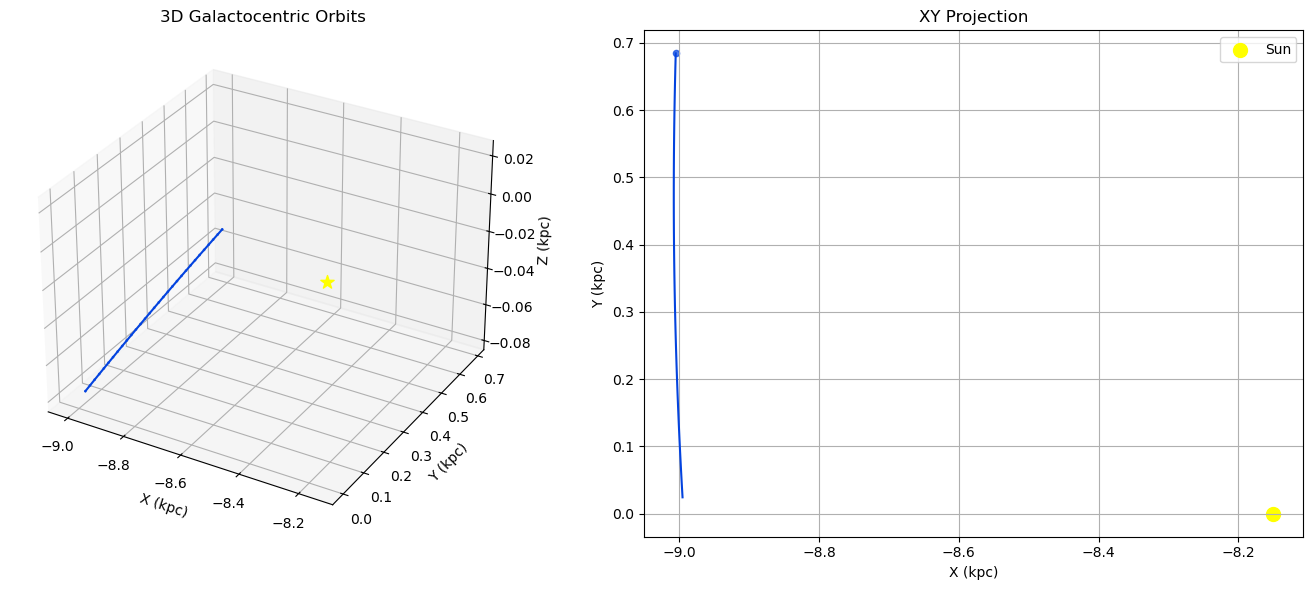

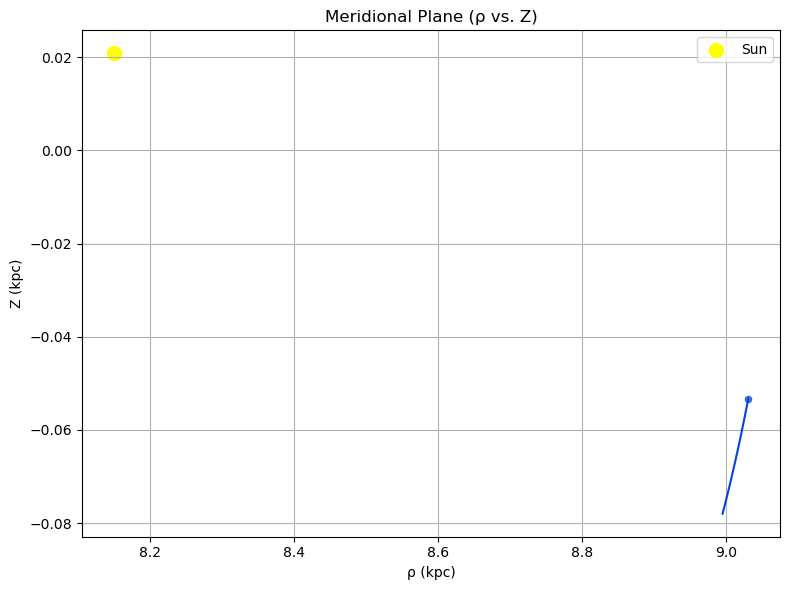

In [24]:
GalacticTraceback(hd7636_table, int_time=-3.0).plot_multiple_stars_in_galactocentric(hd7636_table)

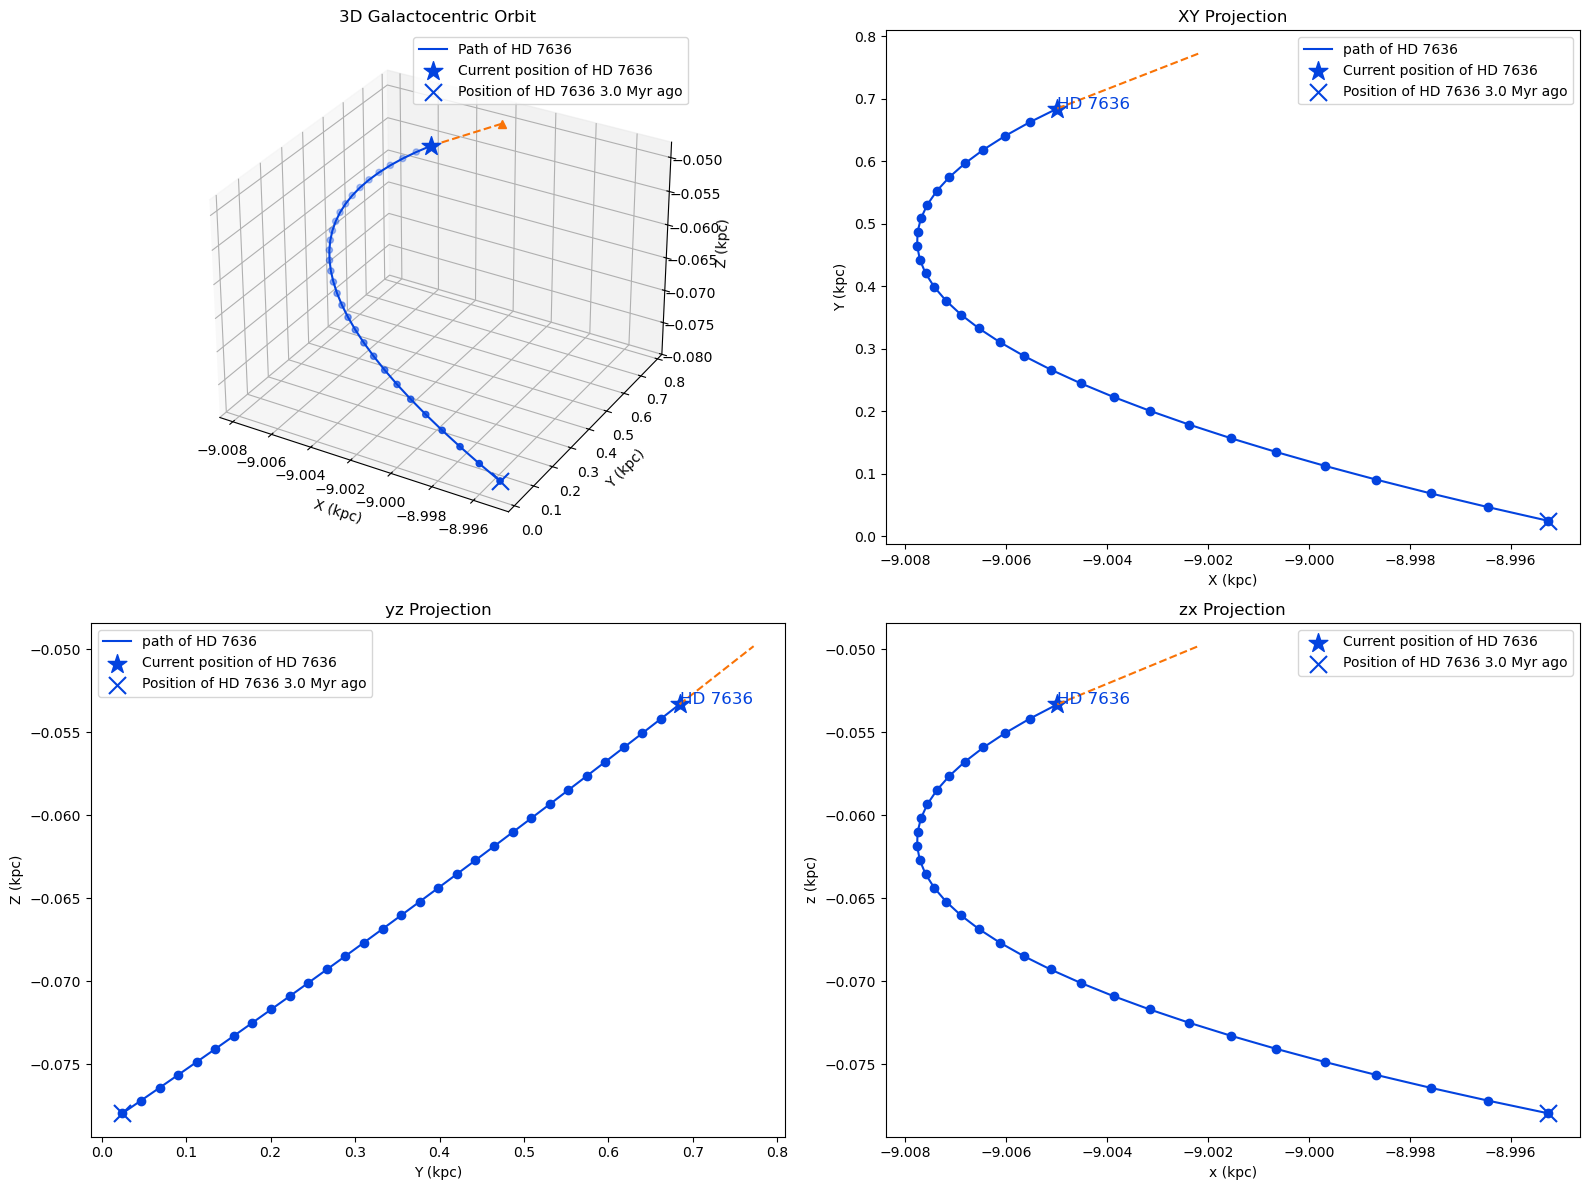

In [25]:
#GalacticTraceback(test_170037, -3.0).plot_in_galactocentric(test_170037, figname='170037_NGC6231',cluster=ngc6231_params,cluster_members=ngc6231_members,savefig=True)
GalacticTraceback(hd7636_table, int_time=-3.0).plot_in_galactocentric(hd7636_table,cluster=None,figname='hd7636')